In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
euro_df = pd.read_csv('../data/fully_cleaned_top_spotify_songs_EU.csv')

features = ['danceability', 'energy', 'speechiness', 'acousticness',
            'liveness', 'valence']

country_names = {
    'BE': 'Belgium', 'DE': 'Germany', 'ES': 'Spain', 'FR': 'France', 'GB': 'United Kingdom',
    'IT': 'Italy', 'NL': 'Netherlands', 'PL': 'Poland', 'PT': 'Portugal', 'SE': 'Sweden'
}

country_avg = euro_df.groupby('country')[features].mean()
country_avg

,danceability,energy,speechiness,acousticness,liveness,valence
country,,,,,,
BE,0.702728,0.653092,0.112215,0.230072,0.144861,0.547368
DE,0.689004,0.725318,0.132280,0.137902,0.189211,0.529682
ES,0.673168,0.640796,0.100927,0.339315,0.154196,0.515844
FR,0.756512,0.642770,0.158255,0.254103,0.121831,0.590458
GB,0.656066,0.665534,0.079561,0.202196,0.172261,0.534233
IT,0.637174,0.661714,0.096896,0.238157,0.175710,0.498106
NL,0.687918,0.705958,0.072931,0.181912,0.155653,0.607634
PL,0.665030,0.673910,0.123111,0.220719,0.176085,0.495431
PT,0.686368,0.627768,0.144456,0.290494,0.163956,0.520996


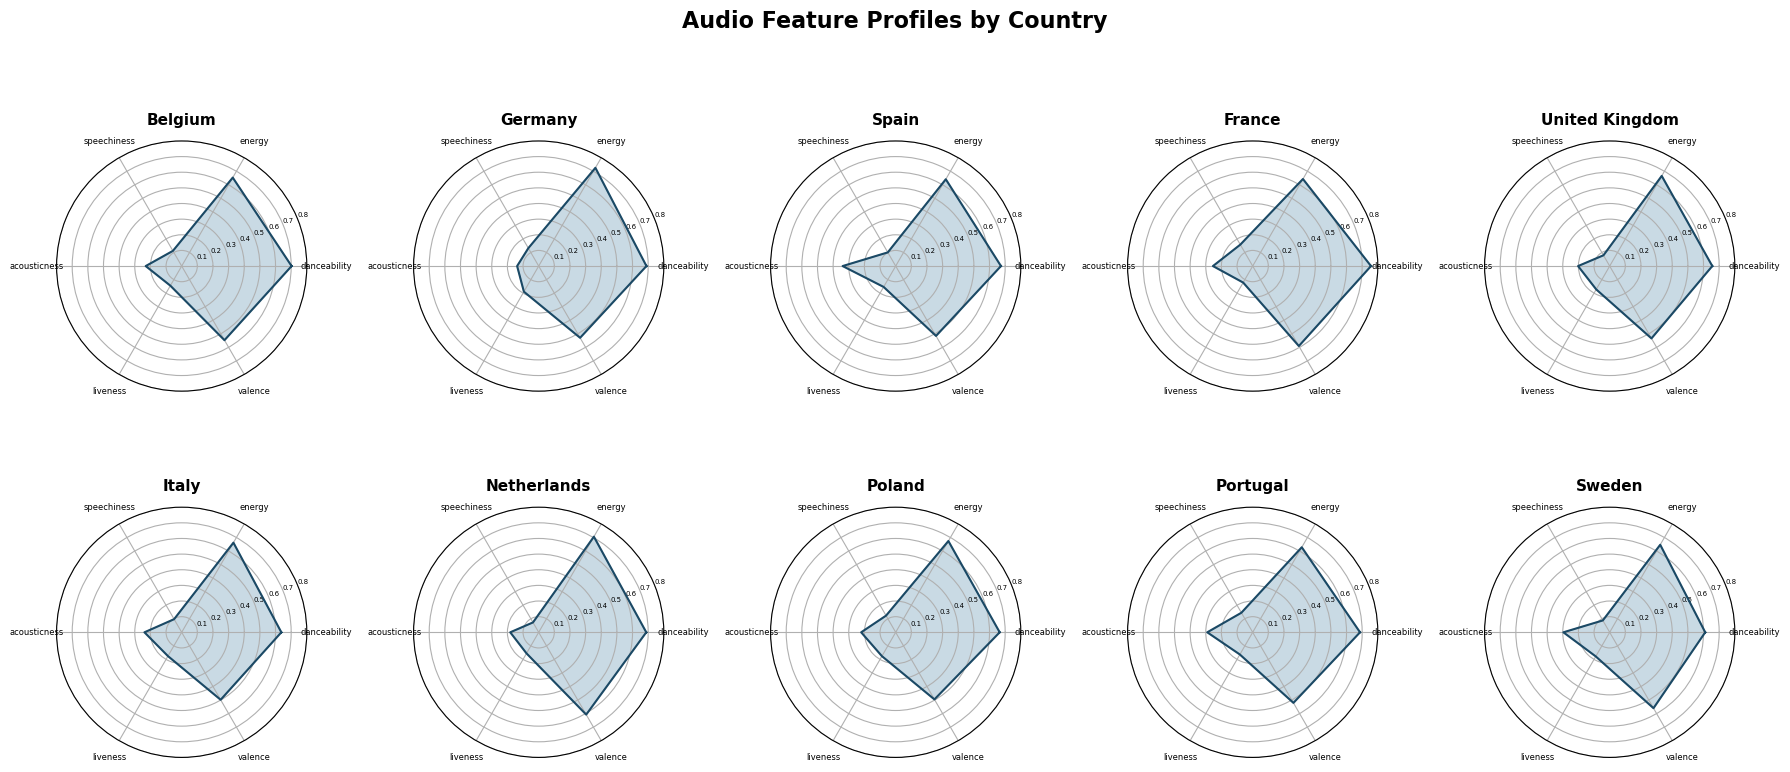

In [13]:
countries = ['BE', 'DE', 'ES', 'FR', 'GB', 'IT', 'NL', 'PL', 'PT', 'SE']
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 5, figsize=(18, 8), subplot_kw=dict(polar=True))
fig.suptitle('Audio Feature Profiles by Country', fontsize=16, fontweight='bold', y=1.02)

for i, code in enumerate(countries):
    row = i // 5
    col = i % 5
    ax = axes[row][col]

    values = country_avg.loc[code].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=1.5, color='#1b4965')
    ax.fill(angles, values, alpha=0.25, color='#2a6f97')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=6)
    ax.set_ylim(0, 0.8)
    ax.set_title(country_names[code], fontsize=11, fontweight='bold', pad=12)
    ax.tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.savefig('radar.png', dpi=150, bbox_inches='tight')
plt.show()